# checked if I could use mspgen for my project. Unfortunately it's not far enough in development

While the Interpreter already works for many protocols, like RIDES2.0, it does not yet recognize essential
keywords, like ’set_repeats’,’v_arrays’,’share’, or ’_protocol_set_’

#### https://gitlab.com/TPfennig/multispeq-pgen/-/tree/main?ref_type=heads

In [1]:
%run utilities_general.ipynb
load_standard_packages()
change_wordir()

import pprint
from pathlib import Path

import numpy as np
import pandas as pd
import photosynq_py as ps

from mspgen import MultispeQProtocol, NonPulsedLight, PulsedLight, load_from_json
from mspgen._utils import download_multispeq_project_protocol

Could not find cannot import name 'dopri5' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'rodas' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'odassl' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find ODEPACK functions.
Could not find RADAR5
Could not find GLIMDA.


1.58.0


In [2]:
# Because this protocol uses the autogain and light_intensity commands, it might take a few seconds
#protocol_path = "/protocols/RIDES_2.0.json"
protocol_path = "protocols/AP_DIRK_ECS_only_hl.json"
#protocol_path = "/protocols/AP_DIRK_P700_only_hl.json"
#protocol_path = "/protocols/AP_PIRK_ECS_only_hl.json"
#protocol_path = "/protocols/AP_PIRK_P700_only_hl.json"


protocol = load_from_json(Path(protocol_path))

ValueError: Unrecognized keyword(s): set_repeats,v_arrays,share,_protocol_set_

In [4]:
# Show the protocol
protocol.head()

tend_ms  taim_ms        tdur_ms description  include  pulses  \
0 0                 0      NaN              0                 True       0   
1 0     a_d2/10 + 150      NaN  a_d2/10 + 150                 True     100   
  1      a_d2/5 + 300      NaN  a_d2/10 + 150                 True     100   
  2  11*a_d2/50 + 330      NaN   a_d2/50 + 30                 True      20   
  3   8*a_d2/25 + 480      NaN  a_d2/10 + 150                 True     100   

     pulse_distance pulse_length pulsed_lights pulsed_lights_brightness  \
0 0               0          [1]          None                     None   
1 0            1500       [a_d2]           [1]                   [a_b2]   
  1            1500       [a_d2]           [1]                   [a_b2]   
  2            1500       [a_d2]           [1]                   [a_b2]   
  3            1500       [a_d2]           [1]                   [a_b2]   

    nonpulsed_lights nonpulsed_lights_brightness detectors  
0 0             None                        None      None  
1 0              [2]           [light_intensity]       [3]  
  1              [2]           [light_intensity]       [3]  
  2              [2]                         [0]       [3]  
  3              [2]           [light_intensity]       [3]

In [5]:
# The variables that need to be set can be found in "symbols"
# Initially, all are set to NaN
protocol.symbols

{light_intensity: nan,
 a_d2: nan,
 a_b2: nan,
 a_b3: nan,
 auto_bright3: nan,
 a_d3: nan}

In [6]:
protocol.set_symbol_values(
    {
        "light_intensity": 1000,  # [µmol(Photons) m2 s-1]
        "a_d2": 600,  # [µs]
        "a_b2": 100,  # [µmol(Photons) m2 s-1]
        "a_d3": 600,  # [µs]
        "a_b3": 100,  # [µmol(Photons) m2 s-1]
        "auto_bright3": 100,  # [µmol(Photons) m2 s-1]
    }
)

C:\Users\andre\OneDrive\Desktop\multispeq-pgen-main\src\mspgen\_protocol.py:701: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  nonp_colors: pd.DataFrame = pd.concat([nonp_colors, _df])


(<Figure size 1500x700 with 2 Axes>,
 array([<Axes: ylabel='Intensity\n[µmol(Photons) m$^{{-2}}$ s$^{{-1}}$]'>,
        <Axes: xlabel='Time [s]', ylabel='Intensity\n[AU (0-4096)]'>],
       dtype=object))

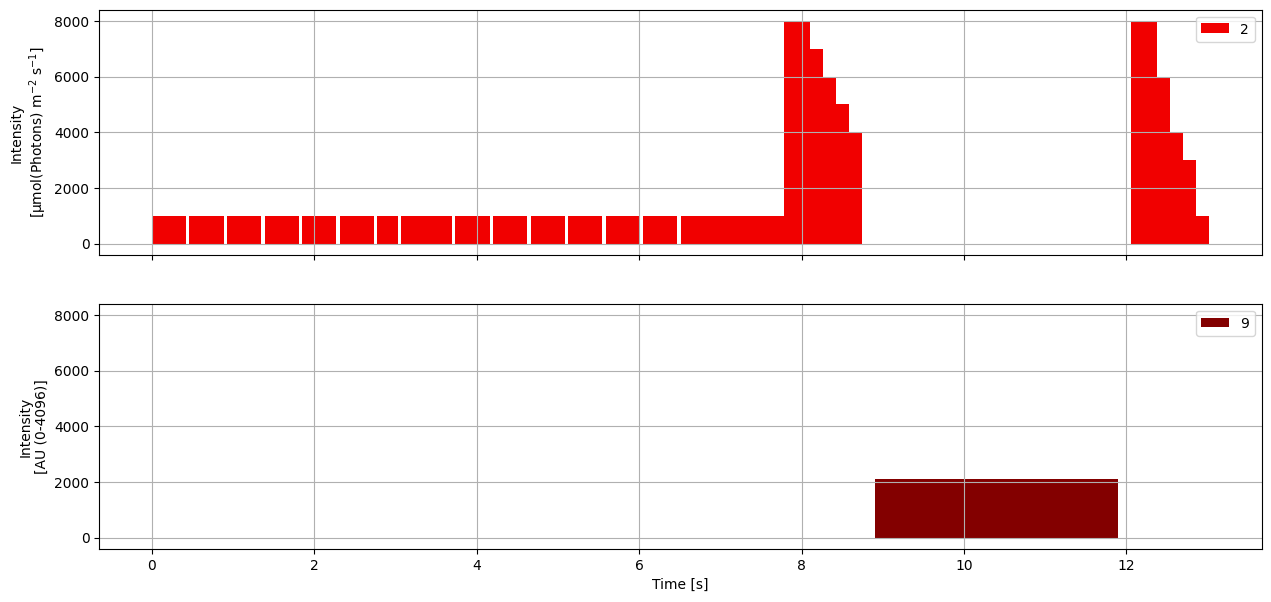

In [7]:
protocol.plot()

In [8]:
protocol.get_lights_timecourse()

C:\Users\andre\OneDrive\Desktop\multispeq-pgen-main\src\mspgen\_protocol.py:701: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  nonp_colors: pd.DataFrame = pd.concat([nonp_colors, _df])


,2,9
Time_s,,
0.21000,1000.0,0.0
0.42000,1000.0,0.0
0.46200,0.0,0.0
0.67200,1000.0,0.0
0.88200,1000.0,0.0
0.92400,0.0,0.0
1.13400,1000.0,0.0
1.34400,1000.0,0.0
1.38600,0.0,0.0


# The tutorial 

## Create a simple protocol

### Initialise the protocol

In [2]:
simple_protocol = MultispeQProtocol()

### View the usable LEDs
The number (`#`) is used to reference them in the `lights` argument of the `Pulsed` or `NonPulsed` classes

In [3]:
simple_protocol.lights

,Colour,Emission Peak,Intensities,Location
#,,,,
1,Green,530 nm,0 - 15000 µmol(Photons) m⁻² s⁻¹,Body
2,Red,655 nm,0 - 15000 µmol(Photons) m⁻² s⁻¹,Body
3,Amber,590 nm,0 - 15000 µmol(Photons) m⁻² s⁻¹,Body
4,Blue,448 nm,0 - 15000 µmol(Photons) m⁻² s⁻¹,Body
5,NIR,950 nm,0 - 4096 AU,Body
6,NIR,950 nm,0 - 4096 AU,Clamp
7,Red,655 nm,0 - 15000 µmol(Photons) m⁻² s⁻¹,Clamp
8,NIR,850 nm,0 - 4096 AU,Clamp
9,Far-Red,730 nm,0 - 4096 AU,Clamp


### View the usable detectors

In [4]:
simple_protocol.detectors

,Detection range,Location,Note
#,,,
1,700 - 1150 nm,Body,
3,400 - 700 nm,Clamp,Detector 3 is covered with a BG-18 bandpass fi...


### Add a constant dark phase
Let's add a dark phase of 1 second (1000 ms).  
For that, define the actinic light that should be used (`NonPulsed`)

In [5]:
# Define a constant light
# Specify the LED(s) that should be used, their brightness and the duration of the phase
dark = NonPulsedLight(
    lights=5,  # The LED(s) used for the light phase
    brightness=0,  # The brightness of the LED(s) in µmol(Photons) m-2 s-1 (or as LED intensity between 0 and 4096 for FR or NIR LEDs)
    duration_ms=1000,  # The duration of the whole light phase in ms
)
dark

        Brightness
Lights            
5                0
Duration: a second

Then, define the measuring light (`Pulsed`).  

In [6]:
# Define the measuring light
measuring = PulsedLight(
    lights=1,  # The LED(s) used for measuring
    brightness=100,  # The brightness of the LED(s) in µmol(Photons) m-2 s-1 (or as LED intensity between 0 and 4096 for FR or NIR LEDs)
    length_us=100,  # The length(s) of the measuring pulses in µs
    distance_us=2e5,  # The distance between the measuring pulses in µs
)
measuring

        Brightness  Length_us
Lights                       
1              100        100
Pulse distance: 200 milliseconds

Finally, add the light phase to the protocol using the `add_pulseset_const` method.

In [8]:
# Add the light phase to the protocol
simple_protocol.add_pulseset_constant_light(
    actinic=dark,  # The actinic light we defined (must be NonPulsed class)
    measuring=measuring,  # The measuring light we defined earlier (must be Pulsed class)
    description=f"dark phase",  # An optional description of the light
    detectors=[3],  # The detectors used to measure the fluorescence
)

### Look at the protocol

In [9]:
simple_protocol

,tend_ms,taim_ms,tdur_ms,description,include,pulses,pulse_distance,pulse_length,pulsed_lights,pulsed_lights_brightness,nonpulsed_lights,nonpulsed_lights_brightness,detectors
0,1000.5,1000,1000.5,dark phase,True,5,200000,[100],[1],[100],[5],[0],[3]
1,2001.0,1000,1000.5,dark phase,True,5,200000,[100],[1],[100],[5],[0],[3]


We see that the protocol only cotains the constant light we added.  
The light phase has a duration of 1000.5 ms (`tdur_ms`) although we aimed for 1000 ms (`taim_ms`).  
This was the closes the we could get to our target duration with the `Pulsed` light duration and distance we specified.  
Setting lower values for these arguments allows for a lower deviance from our target duration.  

### Add more light phases
First, let's add 5 s of blue light, we use the same measuring light as before

In [10]:
# Add a light phase with blue light to the protocol
actinic = NonPulsedLight(
    lights=4,  # The LED(s) used for the light phase
    brightness=100,  # The brightness of the LED(s) in µmol(Photons) m-2 s-1 (or as LED intensity between 0 and 4096 for FR or NIR LEDs)
    duration_ms=5000,  # The duration of the whole light phase in ms
)

simple_protocol.add_pulseset_constant_light(
    actinic=actinic,  # The actinic light we defined (must be NonPulsed class)
    measuring=measuring,  # The measuring light we defined earlier (must be Pulsed class)
    description="constant blue light",  # An optional description of the light
    detectors=[3],  # The detectors used to measure the fluorescence
)

In [11]:
simple_protocol.protocol

,tend_ms,taim_ms,tdur_ms,description,include,pulses,pulse_distance,pulse_length,pulsed_lights,pulsed_lights_brightness,nonpulsed_lights,nonpulsed_lights_brightness,detectors
0,1000.5,1000,1000.5,dark phase,True,5,200000,[100],[1],[100],[5],[0],[3]
1,2001.0,1000,1000.5,dark phase,True,5,200000,[100],[1],[100],[5],[0],[3]
2,7003.5,5000,5002.5,constant blue light,True,25,200000,[100],[1],[100],[4],[100],[3]


### Now, let's add a red light phase
Because we like the light settings we used before, we reuse the `actinic` variable we defined before and only change the light color.

In [12]:
simple_protocol.add_pulseset_constant_light(
    actinic=actinic.copy_altered(
        lights=2
    ),  # The actinic light we defined. The copy_altered method uses the settings we made before but replaced the setting of lights with our new value (2)
    measuring=measuring,  # The measuring light we defined earlier (must be Pulsed class)
    description="constant red light",  # An optional description of the light
    detectors=[3],  # The detectors used to measure the fluorescence
)

### Take a final look at our protocol

In [13]:
simple_protocol

,tend_ms,taim_ms,tdur_ms,description,include,pulses,pulse_distance,pulse_length,pulsed_lights,pulsed_lights_brightness,nonpulsed_lights,nonpulsed_lights_brightness,detectors
0,1000.5,1000,1000.5,dark phase,True,5,200000,[100],[1],[100],[5],[0],[3]
1,2001.0,1000,1000.5,dark phase,True,5,200000,[100],[1],[100],[5],[0],[3]
2,7003.5,5000,5002.5,constant blue light,True,25,200000,[100],[1],[100],[4],[100],[3]
3,12006.0,5000,5002.5,constant red light,True,25,200000,[100],[1],[100],[2],[100],[3]


## Check the protocol
During protocol creating, some problems may have occured.  
E.g. because of the wrong settings for our Pulsed lights, a phase's duration may be far of our target.  
To check this, use the `check` method.

In [14]:
simple_protocol.check()

All checks passed.
Not too many pulse sets:        ✓
Correct number of pulses:       ✓
Correct types of entries:       ✓
Target phase duration matched:  ✓


## Plot the protocol

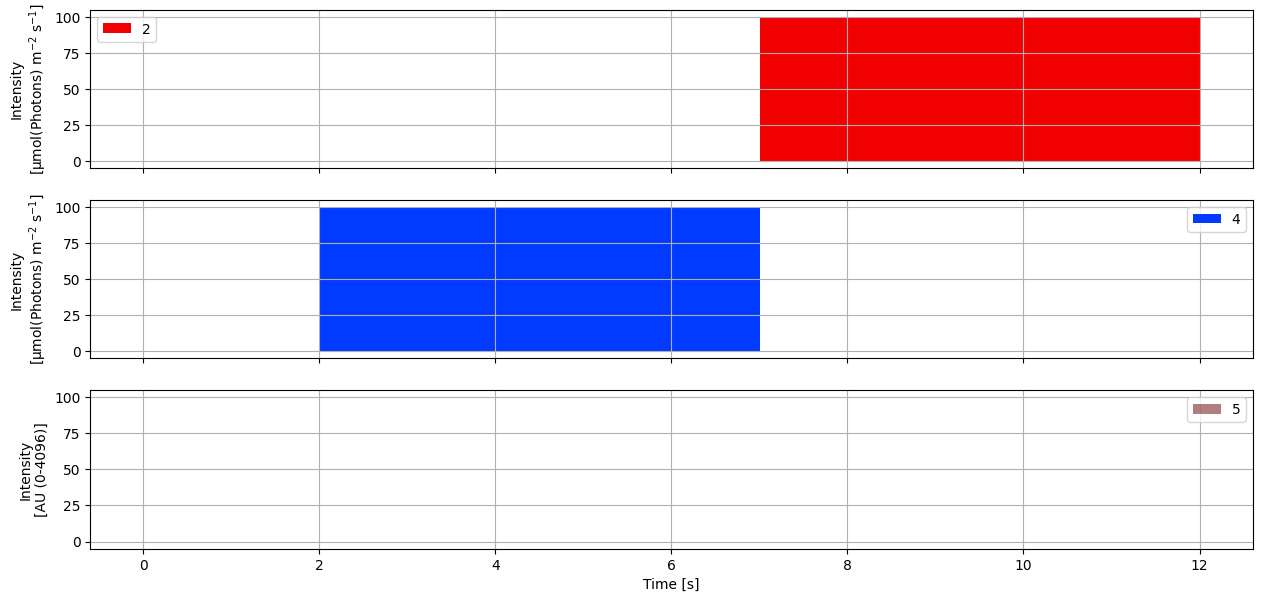

In [15]:
fig, axs = simple_protocol.plot()

## Save protocol to json

In [16]:
simple_protocol.to_json(file_path=Path("../Protocols/simple_protocol.json"))

## Creating a protocol with the PAM Saturation Pulse method

In [17]:
# MultispeQProtocol with initial dark phase
# Define the actinic and saturating lights
actinic = NonPulsedLight(lights=2, brightness=200, duration_ms=1e4)
dark = actinic.copy_altered(brightness=0)
saturating = actinic.copy_altered(brightness=15000, duration_ms=600)

# Define the measuring light
measuring = PulsedLight(lights=7, brightness=100, length_us=30, distance_us=1e5)

# Initialise the protocol
pamsp_protocol = MultispeQProtocol()

# Add a dark acclimation period using the add_pulseset_const method
pamsp_protocol.add_pulseset_constant_light(
    actinic=dark, measuring=measuring, detectors=1, description="dark acclimation"
)

# Add a PAMSP phase with saturation pulse in the dark
pamsp_protocol.add_pulseset_pamsp(
    actinic=dark,
    saturating=saturating,
    measuring=measuring,
    cycles=5,
    detectors=1,
)

# Add a PAMSP phase with saturation pulse in red light
pamsp_protocol.add_pulseset_pamsp(
    actinic=actinic, saturating=saturating, measuring=measuring, cycles=5, detectors=1
)

# Add a PAMSP phase with saturation pulse in the dark
pamsp_protocol.add_pulseset_pamsp(
    actinic=dark,
    saturating=saturating,
    measuring=measuring,
    cycles=5,
    detectors=1,
)

pamsp_protocol.print_stats()

Number of pulses: 	1690
                    Total runtime: 		2 minutes
                    


## Look at the protocol

In [18]:
# Show the protocol as a Dataframe
pamsp_protocol

,tend_ms,taim_ms,tdur_ms,description,include,pulses,pulse_distance,pulse_length,pulsed_lights,pulsed_lights_brightness,nonpulsed_lights,nonpulsed_lights_brightness,detectors
0,10003.00,10000,10003.00,dark acclimation,True,100,100000,[30],[7],[100],[2],[0],[1]
1,20006.00,10000,10003.00,PAM: actinic light,True,100,100000,[30],[7],[100],[2],[0],[1]
2,20606.18,600,600.18,PAM: saturation pulse,True,6,100000,[30],[7],[100],[2],[15000],[1]
3,30609.18,10000,10003.00,PAM: actinic light,True,100,100000,[30],[7],[100],[2],[0],[1]
4,31209.36,600,600.18,PAM: saturation pulse,True,6,100000,[30],[7],[100],[2],[15000],[1]
5,41212.36,10000,10003.00,PAM: actinic light,True,100,100000,[30],[7],[100],[2],[0],[1]
6,41812.54,600,600.18,PAM: saturation pulse,True,6,100000,[30],[7],[100],[2],[15000],[1]
7,51815.54,10000,10003.00,PAM: actinic light,True,100,100000,[30],[7],[100],[2],[0],[1]
8,52415.72,600,600.18,PAM: saturation pulse,True,6,100000,[30],[7],[100],[2],[15000],[1]
9,62418.72,10000,10003.00,PAM: actinic light,True,100,100000,[30],[7],[100],[2],[0],[1]


In [19]:
# Check if the protcol has errors
pamsp_protocol.check()

All checks passed.
Not too many pulse sets:        ✓
Correct number of pulses:       ✓
Correct types of entries:       ✓
Target phase duration matched:  ✓


(<Figure size 1500x700 with 1 Axes>,
 array([<Axes: xlabel='Time [s]', ylabel='Intensity\n[µmol(Photons) m$^{{-2}}$ s$^{{-1}}$]'>],
       dtype=object))

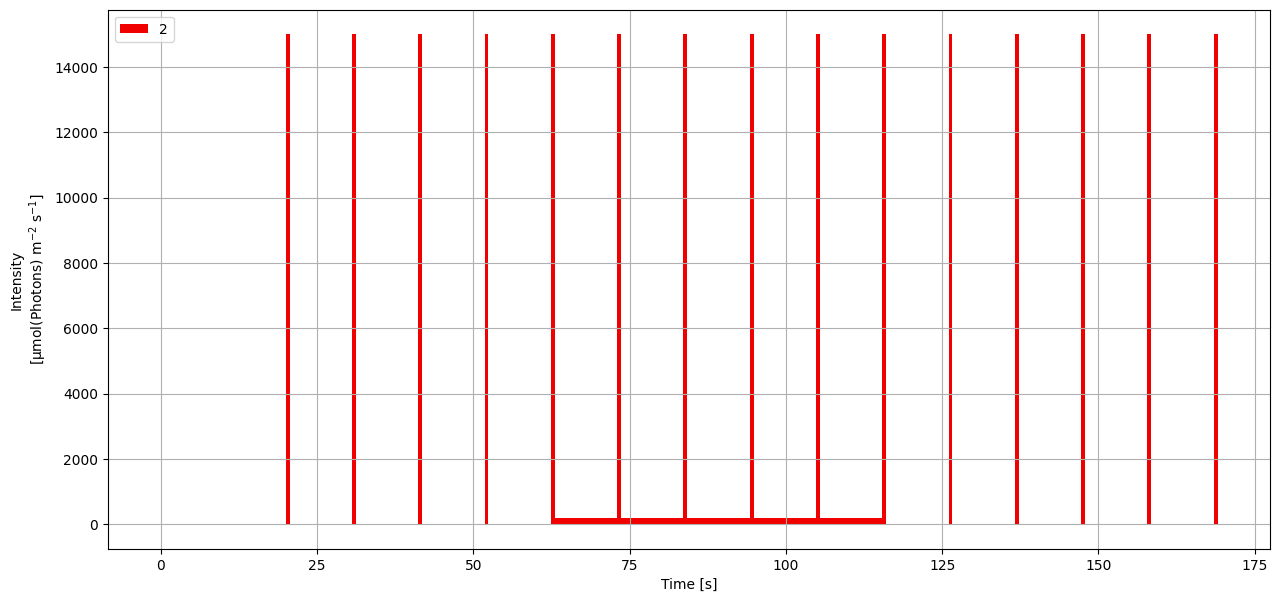

In [20]:
# Plot the protocol
pamsp_protocol.plot()

## Creating a complex protocol
The Protocol contains multiple PAM-SP phases with different light colors

In [ ]:
# Define the period in which saturation pulses should be given
SP_period = 15000  # ms

# Define the frequency of measuring pulses for phases with low (MF_L) and high (MF_H) measuring frequency and during saturation pulses (MF_SP)
MF_L = 1  # s-1
MF_H = 2  # s-1
MF_SP = 10  # s-1

# Define the lights, brightness and duration of the measuring pulses
ML_lights = 7
ML_brightness = 2000
ML_length = 100  # us

# Define the length od a saturation pulse
SP_length = 600  # ms

# Set if each PAMSP phase should be created as a new __protocol_set__
new_sets = True

# Set if the PAMSP phases should be created using protocol_repeats rather than multiple pulse sets
as_repeats = True

# Initialise the protocol
complex_protocol = MultispeQProtocol()

# Initial dark phase
complex_protocol.add_pulseset_constant_light(
    actinic=NonPulsedLight(lights=2, brightness=0, duration_ms=1e4),
    measuring=PulsedLight(
        lights=ML_lights,
        brightness=ML_brightness,
        length_us=ML_length,
        frequency_hz=MF_L,
    ),
    description="dark acclimation",
)

# Saturation pulses in dark, SP every 15 s
complex_protocol.add_pulseset_pamsp(
    actinic=NonPulsedLight(lights=2, brightness=0, duration_ms=SP_period - SP_length),
    saturating=NonPulsedLight(lights=2, brightness=15000, duration_ms=SP_length),
    measuring=(
        PulsedLight(
            lights=ML_lights,
            brightness=ML_brightness,
            length_us=ML_length,
            frequency_hz=MF_H,
        ),
        PulsedLight(
            lights=ML_lights,
            brightness=ML_brightness,
            length_us=ML_length,
            frequency_hz=MF_SP,
        ),
    ),
    cycles=3,
)

# PAM protocol with changing AL colours, SP every 15 s
for AL_lights, AL_ints, phase_time_s in [
    # Original attempt
    (2, 100, 60),  # 655 nm
    (1, 100, 60),  # 530 nm
    (4, 100, 60),  # 448 nm
    (2, 100, 180),  # 655 nm
    (4, 100, 60),  # 448 nm
    (2, 100, 180),  # 655 nm
    (4, 2000, 120),  # 448 nm
    # (2, 100, 60), # 655 nm
    # (4, 100, 60), # 448 nm
    # (2, 100, 180), # 655 nm
    # (4, 100, 60), # 448 nm
    # (2, 100, 180), # 655 nm
    # (4, 2000, 240), # 448 nm
    # # (4, 0, 240), # dark
]:
    complex_protocol.add_pulseset_pamsp(
        actinic=NonPulsedLight(
            lights=AL_lights, brightness=AL_ints, duration_ms=SP_period - SP_length
        ),
        saturating=NonPulsedLight(lights=2, brightness=15000, duration_ms=SP_length),
        measuring=(
            PulsedLight(
                lights=ML_lights,
                brightness=ML_brightness,
                length_us=ML_length,
                frequency_hz=MF_H,
            ),
            PulsedLight(
                lights=ML_lights,
                brightness=ML_brightness,
                length_us=ML_length,
                frequency_hz=MF_SP,
            ),
        ),
        cycles=int(phase_time_s / (SP_period * 1e-3)),
        descriptions=[f"PAM {AL_lights}: actinic", f"PAM {AL_lights}: saturating"],
        new_protocol_set=new_sets,
        as_repeats=as_repeats,
    )

complex_protocol.add_pulseset_constant_light(
    actinic=NonPulsedLight(lights=2, brightness=0, duration_ms=1e4),
    measuring=PulsedLight(
        lights=ML_lights,
        brightness=ML_brightness,
        length_us=ML_length,
        frequency_hz=MF_L,
    ),
    description="dark after",
    new_protocol_set=new_sets,
)

complex_protocol.check()

In [ ]:
complex_protocol.plot(ylim=(0, 2500))

In [ ]:
# Show the protocol
complex_protocol

Notice that the index on the left side has two columns:
- A first one from 0 to 8 and 
- a second one that increases from 0 but starts new for every new value of the first index.

The number of the set in __protocols_sets__ that the respective puls set is a part of.  
The second index is the index of the pulse set within that protocol.

In [ ]:
# Save protocol
complex_protocol.to_json(file_path=Path("../Protocols/complex_protocol.json"))

## Read JSON Protocols

### Reading a simple protocol

In [ ]:
read_protocol = load_from_json(Path("../Protocols/simple_protocol.json"))
read_protocol

In [ ]:
read_protocol.plot()

## Reading a complex protocol from the PhotosynQ website

### Download the protocol "Photosynthesis RIDES 2.0"

In [25]:
ps.login()

Logged in successfully as andre.potthoff@hhu.de


In [27]:
# Define a list with the published protocols and their associated protocol ID
# Here, only "Photosynthesis RIDES 2.0" as an example
published_protocols = {"Photosynthesis RIDES 2.0": 2324}

# Test if all protocols have been downloaded
incomplete_download = np.any(
    np.array(
        [
            len(list(Path("Protocols").glob(f"{id}-*")))
            for id in published_protocols.values()
        ]
    )
    == 0
)

# Only donwload protocols if they are not yet present
if incomplete_download:
    # Use your photosynq account to login (you will be prompted for your username and password)
    ps.login()

    # Iterate through the published protocols and save them
    for nam, id in published_protocols.items():
        # Load the protocol from the PhotosynQ website
        protocol_full = download_multispeq_project_protocol(id)

        # Write the protocol to JSON in the Protocols folder
        with Path(f"../Protocols/{id}-{protocol_full['slug']}.json").open("w") as f:
            pretty_json_str = pprint.pformat(
                [protocol_full["protocol_json"]], compact=True
            ).replace("'", '"')
            f.write(pretty_json_str)

    ps.logout()

Exception: Already logged in as andre.potthoff@hhu.de. Use logout() first.

### Read the protocol from JSON

In [28]:
# Importing the protocol
# Because this protocol uses the autogain and light_intensity commands, it might take a few seconds
rides_protocol = load_from_json(Path("../protocols/RIDES_2.0.json"))

Importing Protocol:   0%|          | 0/5 [00:00<?, ?it/s]

C:\Users\andre\OneDrive\Desktop\multispeq-pgen-main\src\mspgen\_import.py:91: UserWarning: Not all entries have the same length in protocol set No. 3. Looping given entries.
  warn(


In [29]:
# Show the protocol
rides_protocol

tend_ms  taim_ms               tdur_ms  \
0 0                                       0      NaN                     0   
1 0                           a_d2/10 + 150      NaN         a_d2/10 + 150   
  1                            a_d2/5 + 300      NaN         a_d2/10 + 150   
  2                        11*a_d2/50 + 330      NaN          a_d2/50 + 30   
  3                         8*a_d2/25 + 480      NaN         a_d2/10 + 150   
  4                        21*a_d2/50 + 630      NaN         a_d2/10 + 150   
  5                        11*a_d2/25 + 660      NaN          a_d2/50 + 30   
  6                        27*a_d2/50 + 810      NaN         a_d2/10 + 150   
  7                        16*a_d2/25 + 960      NaN         a_d2/10 + 150   
  8                        33*a_d2/50 + 990      NaN          a_d2/50 + 30   
  9                       19*a_d2/25 + 1140      NaN         a_d2/10 + 150   
  10                      43*a_d2/50 + 1290      NaN         a_d2/10 + 150   
  11                      22*a_d2/25 + 1320      NaN          a_d2/50 + 30   
  12                      49*a_d2/50 + 1470      NaN         a_d2/10 + 150   
  13                      27*a_d2/25 + 1620      NaN         a_d2/10 + 150   
  14                      11*a_d2/10 + 1650      NaN          a_d2/50 + 30   
  15                        6*a_d2/5 + 1800      NaN         a_d2/10 + 150   
  16                      13*a_d2/10 + 1950      NaN         a_d2/10 + 150   
  17                      33*a_d2/25 + 1980      NaN          a_d2/50 + 30   
  18                      71*a_d2/50 + 2130      NaN         a_d2/10 + 150   
  19                      36*a_d2/25 + 2160      NaN          a_d2/50 + 30   
  20                      73*a_d2/50 + 2190      NaN          a_d2/50 + 30   
  21                      39*a_d2/25 + 2340      NaN         a_d2/10 + 150   
2 0             39*a_d2/25 + a_d3/10 + 2490      NaN         a_d3/10 + 150   
  1              39*a_d2/25 + a_d3/5 + 2640      NaN         a_d3/10 + 150   
  2          39*a_d2/25 + 11*a_d3/50 + 2670      NaN          a_d3/50 + 30   
  3           39*a_d2/25 + 8*a_d3/25 + 2820      NaN         a_d3/10 + 150   
  4          39*a_d2/25 + 21*a_d3/50 + 2970      NaN         a_d3/10 + 150   
  5          39*a_d2/25 + 11*a_d3/25 + 3000      NaN          a_d3/50 + 30   
  6          39*a_d2/25 + 27*a_d3/50 + 3150      NaN         a_d3/10 + 150   
  7          39*a_d2/25 + 16*a_d3/25 + 3300      NaN         a_d3/10 + 150   
  8          39*a_d2/25 + 33*a_d3/50 + 3330      NaN          a_d3/50 + 30   
  9          39*a_d2/25 + 19*a_d3/25 + 3480      NaN         a_d3/10 + 150   
  10         39*a_d2/25 + 43*a_d3/50 + 3630      NaN         a_d3/10 + 150   
  11         39*a_d2/25 + 22*a_d3/25 + 3660      NaN          a_d3/50 + 30   
  12         39*a_d2/25 + 49*a_d3/50 + 3810      NaN         a_d3/10 + 150   
  13         39*a_d2/25 + 27*a_d3/25 + 3960      NaN         a_d3/10 + 150   
  14         39*a_d2/25 + 11*a_d3/10 + 3990      NaN          a_d3/50 + 30   
  15           39*a_d2/25 + 6*a_d3/5 + 4140      NaN         a_d3/10 + 150   
  16         39*a_d2/25 + 13*a_d3/10 + 4290      NaN         a_d3/10 + 150   
  17         39*a_d2/25 + 33*a_d3/25 + 4320      NaN          a_d3/50 + 30   
  18         39*a_d2/25 + 71*a_d3/50 + 4470      NaN         a_d3/10 + 150   
  19         39*a_d2/25 + 38*a_d3/25 + 4620      NaN         a_d3/10 + 150   
  20         39*a_d2/25 + 77*a_d3/50 + 4650      NaN          a_d3/50 + 30   
  21         39*a_d2/25 + 41*a_d3/25 + 4800      NaN         a_d3/10 + 150   
3 0          39*a_d2/25 + 87*a_d3/50 + 5803      NaN        a_d3/10 + 1003   
  1    39*a_d2/25 + 177*a_d3/100 + 61039/10      NaN  3*a_d3/100 + 3009/10   
  2   39*a_d2/25 + 357*a_d3/200 + 125087/20      NaN  3*a_d3/200 + 3009/20   
  3         39*a_d2/25 + 9*a_d3/5 + 32024/5      NaN  3*a_d3/200 + 3009/20   
  4     39*a_d2/25 + 363*a_d3/200 + 26221/4      NaN  3*a_d3/200 + 3009/20   
  5    39*a_d2/25 + 183*a_d3/100 + 67057/10      NaN  3*a_

This protocol uses the measured environmental irradiance (light_intensity) and employs autogain to set the pulse duration and intensity.  
These values are kept as variables in the protocol and can be set using the `set_symbol_value` method:

In [30]:
# The variables that need to be set can be found in "symbols"
# Initially, all are set to NaN
rides_protocol.symbols

{auto_bright3: nan,
 a_b3: nan,
 a_b2: nan,
 a_d2: nan,
 light_intensity: nan,
 a_d3: nan}

In [31]:
# Set the variable durations and brightnesses in the protocol
rides_protocol.set_symbol_values(
    {
        "light_intensity": 1000,  # [µmol(Photons) m2 s-1]
        "a_d2": 600,  # [µs]
        "a_b2": 100,  # [µmol(Photons) m2 s-1]
        "a_d3": 600,  # [µs]
        "a_b3": 100,  # [µmol(Photons) m2 s-1]
        "auto_bright3": 100,  # [µmol(Photons) m2 s-1]
    }
)

In [32]:
# Get the protocol with the variables replaced with their new values
rides_protocol.get_protocol().head()

tend_ms  taim_ms  tdur_ms description  include  pulses  pulse_distance  \
0 0      0.0      NaN      0.0                 True       0               0   
1 0    210.0      NaN    210.0                 True     100            1500   
  1    420.0      NaN    210.0                 True     100            1500   
  2    462.0      NaN     42.0                 True      20            1500   
  3    672.0      NaN    210.0                 True     100            1500   

    pulse_length pulsed_lights pulsed_lights_brightness nonpulsed_lights  \
0 0          [1]          None                     None             None   
1 0      [600.0]           [1]                  [100.0]              [2]   
  1      [600.0]           [1]                  [100.0]              [2]   
  2      [600.0]           [1]                  [100.0]              [2]   
  3      [600.0]           [1]                  [100.0]              [2]   

    nonpulsed_lights_brightness detectors  
0 0                        None      None  
1 0                    [1000.0]       [3]  
  1                    [1000.0]       [3]  
  2                         [0]       [3]  
  3                    [1000.0]       [3]

When these values are set, the protocol can be plotted

C:\Users\andre\OneDrive\Desktop\multispeq-pgen-main\src\mspgen\_protocol.py:701: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  nonp_colors: pd.DataFrame = pd.concat([nonp_colors, _df])


(<Figure size 1500x700 with 2 Axes>,
 array([<Axes: ylabel='Intensity\n[µmol(Photons) m$^{{-2}}$ s$^{{-1}}$]'>,
        <Axes: xlabel='Time [s]', ylabel='Intensity\n[AU (0-4096)]'>],
       dtype=object))

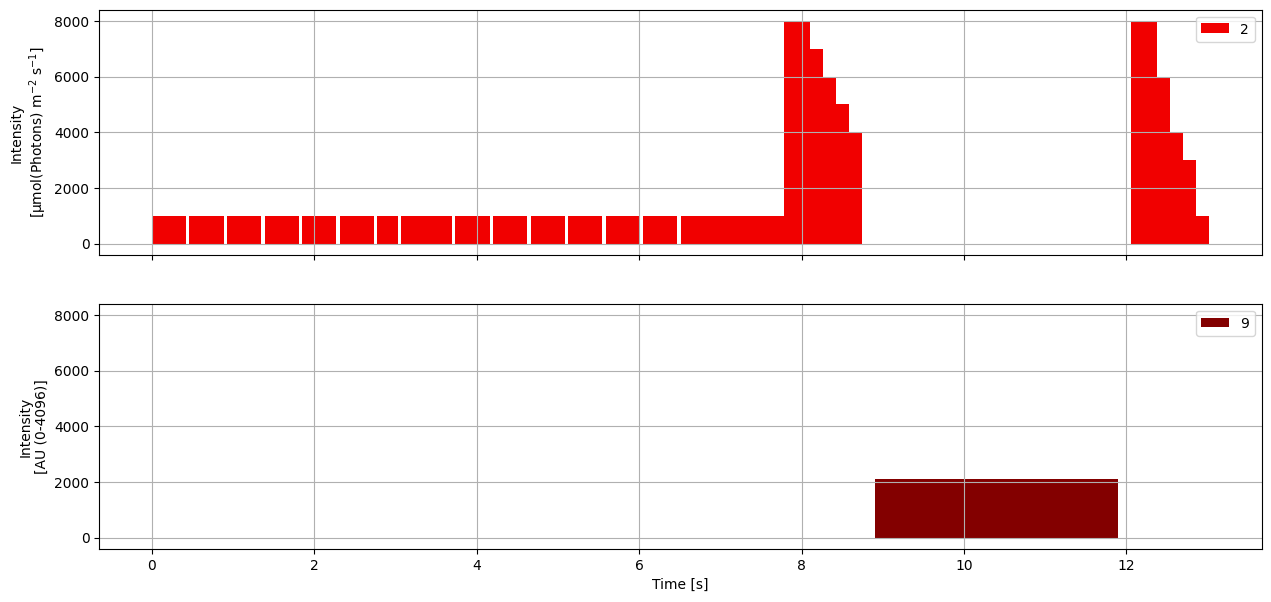

In [33]:
rides_protocol.plot()

## Get the protocol as for modelling
The function `get_lights_timecourse` retunr a dataframe with the index being the end time of a protocol phase in seconds - this could, for example, be used as t_end in ode integrators.   
The columns represent each involved non-pulsed light with its respective light intensity (see the protocol's `light` argument for information on the unit)

In [34]:
rides_protocol.get_lights_timecourse()

C:\Users\andre\OneDrive\Desktop\multispeq-pgen-main\src\mspgen\_protocol.py:701: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  nonp_colors: pd.DataFrame = pd.concat([nonp_colors, _df])


,2,9
Time_s,,
0.21000,1000.0,0.0
0.42000,1000.0,0.0
0.46200,0.0,0.0
0.67200,1000.0,0.0
0.88200,1000.0,0.0
0.92400,0.0,0.0
1.13400,1000.0,0.0
1.34400,1000.0,0.0
1.38600,0.0,0.0
